Use a function to map the (DH0, n_sigma) to 1D and estimate the probability.

The function chosen for the main result, the lower bound
$\text{lower bound} = \Delta H_0 - \Delta H_0/n_\sigma$

## Load functions

In [1]:
# ---------------------------------------------------------------------------- #
#                                   Functions                                  #
# ---------------------------------------------------------------------------- #
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from scipy.stats import genpareto
import matplotlib.pyplot as plt
from scipy.special import erfinv
import math
import clusterplot as cp
plt.style.use('./nice.mplstyle')

def load_data(file_path, data_type='mc'):
    data = pd.read_csv(file_path)
    if data_type == 'direct_compare':
        data['Delta_H0'] *= 100
    return data

def extract_data(data, relation):
    df = data[data['Relations'] == relation]
    if 'Delta_H0' in df.columns:
        delta_h0 = df['Delta_H0'].values
    else:
        delta_h0 = df['$\Delta H_0\,(\%)$'].values
    if 'Significance $(\sigma)$' in df.columns:
        significance = df['Significance $(\sigma)$'].values
    else:
        significance = df['Significance'].values
    return delta_h0, significance

def calculate_sigma_p_value(delta_h0_proj, target_value):
    median = np.median(delta_h0_proj)
    sigma_84th = np.percentile(delta_h0_proj, 84)
    sigma = sigma_84th - median
    sigma_deviation = np.abs((target_value - median) / sigma)
    p_value_sigma = 1 - math.erf(sigma_deviation / np.sqrt(2))
    return sigma_deviation, p_value_sigma

def calculate_evt_p_value(delta_h0_proj, target_value, percentile=90):
    # Determine the threshold
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold  # Tail data

    # Fit GPD to the tail data
    params = genpareto.fit(exceedances)
    shape, loc, scale = params

    # Tail survival probability (proportion of data in the tail)
    tail_prob = np.sum(delta_h0_proj >= threshold) / len(delta_h0_proj)

    if target_value > threshold:
        # Conditional probability adjusted to match at the threshold
        p_value_evt = (1 - genpareto.cdf(target_value - threshold, *params)) * tail_prob
    else:
        # Empirical CDF for the bulk region
        p_value_evt = np.sum(delta_h0_proj >= target_value) / len(delta_h0_proj)

    # Transform to sigma (Gaussian equivalent deviation)
    sigma_deviation = np.sqrt(2) * erfinv(1 - p_value_evt)

    return p_value_evt, sigma_deviation

# The first projection function
def default_proj(delta_H0, n_sigma):
    return delta_H0 - delta_H0 / n_sigma

/cosma/home/do012/dc-he4/.conda/envs/halo-cosma/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Small plots for appendices
The MCMC run, for Lx-T and Ysz-T, output data and plot.

Prob of obtaining (ΔH%, nσ) = [8.7 2.4] in $L_\mathrm{{X}}-T$.
Sigma deviation: 2.88σ, p-value: 0.00403
Probability of target value: 0.0322, (2.14sigma)


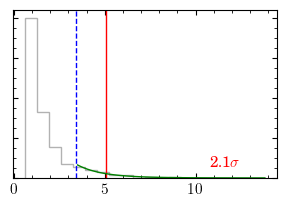

Prob of obtaining (ΔH%, nσ) = [14.   2.6] in $Y_\mathrm{{SZ}}-T$.
Sigma deviation: 9.26σ, p-value: 0
Probability of target value: 0.000276, (3.64sigma)


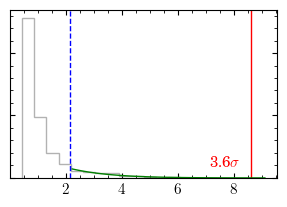

In [ ]:
file_path_mc = '/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mc_all.csv'
data_type_mc = 'mc'
data_mc = load_data(file_path_mc, data_type_mc)

target_point_arr_mc = [np.array([8.7, 2.4]), np.array([14, 2.6])]
for relation, target_point in zip(['$L_\\mathrm{{X}}-T$', '$Y_\\mathrm{{SZ}}-T$'], target_point_arr_mc):
    print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in {relation}.')
    delta_h0, significance = extract_data(data_mc, relation)
    delta_h0_proj = default_proj(delta_h0, significance)
    target_value = default_proj(target_point[0], target_point[1])
    
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
    print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")
    
    percentile = 90
    p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
    print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")
    
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params
    
    # Plotting results
    x_vals = np.linspace(threshold, delta_h0_proj.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)

    # Plot
    cp._small_evs_(distribution=delta_h0_proj,
                   target_value=target_value,
                   x_vals=x_vals,
                   gpd_pdf=gpd_pdf,
                   threshold=threshold,
                   percentile=percentile,
                   sigma_evt=sigma_evt, color='gray')

    # plt.savefig(f'./to_paper/evs_mcmc_{relation[1]}.pdf', bbox_inches='tight')   # save the figure
    plt.show()

The M21 fits, of Lx-T and Ysz-T separately. Data and plot below.

Prob of obtaining (ΔH%, nσ) = [8.7 2.6] in $L_\mathrm{{X}}-T$.
Sigma deviation: 1.96σ, p-value: 0.0497
Probability of target value: 0.0247, (2.25sigma)


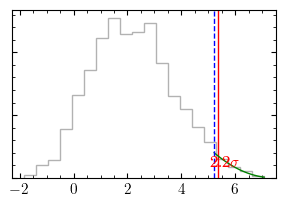

Prob of obtaining (ΔH%, nσ) = [14.   4.1] in $Y_\mathrm{{SZ}}-T$.
Sigma deviation: 6.42σ, p-value: 1.39e-10
Probability of target value: 1.81e-10, (6.38sigma)


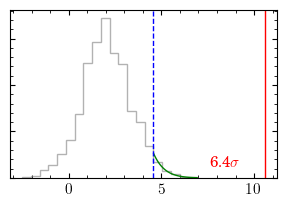

In [ ]:
file_path_direct_compare = '/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_direct_compare.csv'
data_type_direct_compare = 'direct_compare'
data_direct_compare = load_data(file_path_direct_compare, data_type_direct_compare)

target_point_arr_direct_compare = [np.array([8.7, 2.6]), np.array([14, 4.1])]
for relation, target_point in zip(['$L_\\mathrm{{X}}-T$', '$Y_\\mathrm{{SZ}}-T$'], target_point_arr_direct_compare):
    print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in {relation}.')
    delta_h0, significance = extract_data(data_direct_compare, relation)
    delta_h0_proj = default_proj(delta_h0, significance)
    target_value = default_proj(target_point[0], target_point[1])
    
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
    print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")
    
    percentile = 97
    p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
    print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")
    
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params
    
    # Plotting results
    x_vals = np.linspace(threshold, delta_h0_proj.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)

    # Plot
    cp._small_evs_(distribution=delta_h0_proj,
                   target_value=target_value,
                   x_vals=x_vals,
                   gpd_pdf=gpd_pdf,
                   threshold=threshold,
                   percentile=percentile,
                   sigma_evt=sigma_evt, color='gray')

    # plt.savefig(f'./to_paper/evs_m21_{relation[1]}.pdf', bbox_inches='tight')  # save the figure
    plt.show()

## Main results

In [2]:
file_path_joint = '../data/analysis_all/h0_mc_joint_all.csv'
data_joint = load_data(file_path_joint, 'joint')
data_joint = data_joint[data_joint['Lightcone'] != 1318]
print(len(data_joint))
# lightcone 1318 is bugged

1726


In [3]:
# Which ones are not there?
for i in range(1728):
    if i in data_joint['Lightcone'].values:
        continue
    else:
        print(i)

1215
1318


### Bootstrap resampling error

In [4]:
def bootstrap_fit(data, fit_func=genpareto.fit, N=1000):
    # Bootstrap sampling
    all_params = []
    for i in range(N):
        sample = np.random.choice(data, size=len(data), replace=True)
        params = fit_func(sample)
        all_params.append(params)
    all_params = np.array(all_params)

    # Lower and upper one sigma parameters
    lower_params = np.zeros_like(params)
    upper_params = np.zeros_like(params)
    for i in range(len(params)):
        lower_params[i] = np.percentile(a=all_params[:,i], q=16)
        upper_params[i] = np.percentile(a=all_params[:,i], q=84)
        
    return lower_params, upper_params
    

In [5]:
# ** This plot is put in the paper **
target_point = np.array([9.0, 5.9])

print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in joint result.')
delta_h0 = data_joint['DeltaH0'].values
significance = data_joint['Significance'].values
delta_h0_proj = default_proj(delta_h0, significance)
target_value = default_proj(target_point[0], target_point[1])

sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")

percentile = 90
p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")

threshold = np.percentile(delta_h0_proj, percentile)                           # get the threshold                  
exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold # select the exceedance

params = genpareto.fit(exceedances)    # make the genpareto fit
shape, loc, scale = params # extract the parameters

# error bar
params_lower, params_upper = bootstrap_fit(exceedances)
print('fit params:', params_lower, 'to', params_upper)

Prob of obtaining (ΔH%, nσ) = [9.  5.9] in joint result.
Sigma deviation: 6.2σ, p-value: 5.63e-10
Probability of target value: 0.000155, (3.78sigma)


fit params: [-0.2891641   0.00397429  1.24048601] to [-0.12274693  0.03153765  1.57062138]


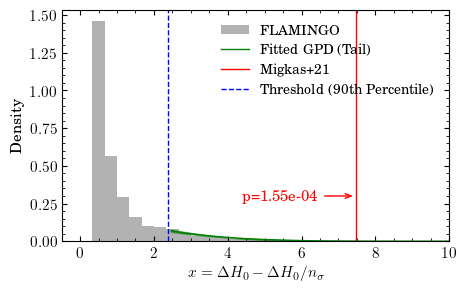

In [ ]:
x_vals = np.linspace(threshold, 10, 100) # x for plotting fitted pdf
gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100) # fitted genpareto distribution
gpd_pdf0 = genpareto.pdf(x_vals - threshold, *params_lower) * (1 - percentile / 100) # lower bound
gpd_pdf1 = genpareto.pdf(x_vals - threshold, *params_upper) * (1 - percentile / 100) # upper bound

# Plotting results for joint result
plt.figure(figsize=(5, 3))
plt.hist(delta_h0_proj, bins=30, range=(0, 10), density=True, alpha=0.6, color='gray', label='FLAMINGO')   # histogram

plt.plot(x_vals[1:], gpd_pdf[1:], color='g', label='Fitted GPD (Tail)')                                    # fitted line
plt.fill_between(x_vals[1:], gpd_pdf0[1:], gpd_pdf1[1:], color='g', alpha=0.5)

plt.axvline(target_value, color='red', linestyle='-', label=f'Migkas+21')                                  # M21 reference line
plt.axvline(threshold, color='blue', linestyle='--', label=f'Threshold ({percentile}th Percentile)') # threshold reference line

# Annotate the plot
plt.annotate(f'p={p_value_evt:.2e}', 
         xy=(target_value, 0.3), xycoords='data',
         xytext=(target_value - 1, 0.3), textcoords='data',
         arrowprops=dict(arrowstyle='->,head_width=.15', color='red'),
         horizontalalignment='right', verticalalignment='center', color='red')

plt.xlabel('$x=\\Delta H_0 - \\Delta H_0 / n_\\sigma$')
plt.ylabel('Density')
plt.xlim(right=10)
# plt.yscale('log')
plt.legend(fontsize=10)

# plt.savefig('./to_paper/evs_joint.pdf', bbox_inches='tight')
plt.show()

In [7]:
print('fit params:', params_lower, 'to', params_upper)

fit params: [-0.2943012   0.00397429  1.23647083] to [-0.13222544  0.03153765  1.56657188]


### Test: use upper bound instead of lower
$\text{upper bound} = \Delta H_0 + \Delta H_0/n_\sigma$

Prob of obtaining (ΔH%, nσ) = [8.7 2.4] in $L_\mathrm{{X}}-T$.
Sigma deviation: 1.5σ, p-value: 0.133
Probability of target value: 0.784, (0.274sigma)


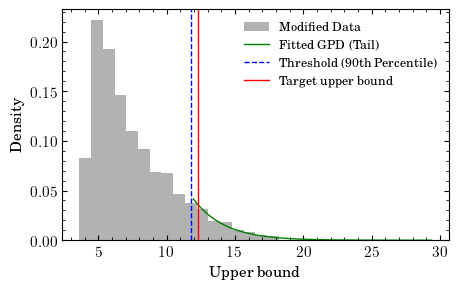

Prob of obtaining (ΔH%, nσ) = [14.   2.6] in $Y_\mathrm{{SZ}}-T$.
Sigma deviation: 5.95σ, p-value: 2.74e-09
Probability of target value: 0.000797, (3.35sigma)


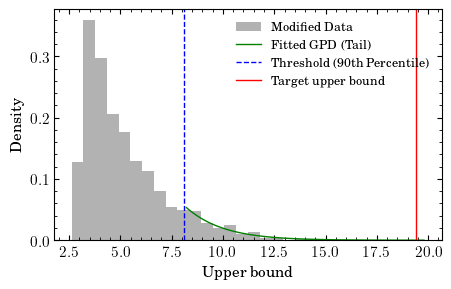

Prob of obtaining (ΔH%, nσ) = [8.7 2.6] in $L_\mathrm{{X}}-T$.
Sigma deviation: 3.24σ, p-value: 0.0012
Probability of target value: 0.0682, (1.82sigma)


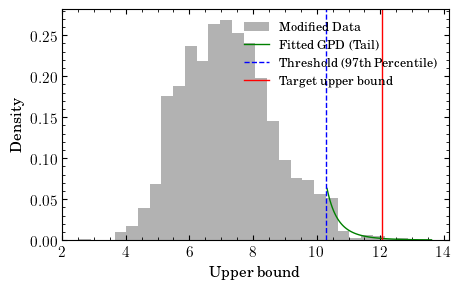

Prob of obtaining (ΔH%, nσ) = [14.   4.1] in $Y_\mathrm{{SZ}}-T$.
Sigma deviation: 8.8σ, p-value: 0
Probability of target value: 1.37e-05, (4.35sigma)


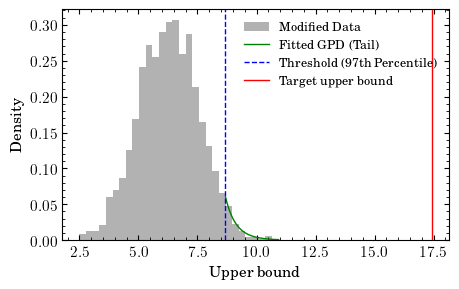

In [17]:
# The first projection function
def default_proj(delta_H0, n_sigma):
    return delta_H0 + delta_H0 / n_sigma

# Example usage for mc data
file_path_mc = '/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mc_all.csv'
data_type_mc = 'mc'
data_mc = load_data(file_path_mc, data_type_mc)

target_point_arr_mc = [np.array([8.7, 2.4]), np.array([14, 2.6])]
for relation, target_point in zip(['$L_\\mathrm{{X}}-T$', '$Y_\\mathrm{{SZ}}-T$'], target_point_arr_mc):
    print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in {relation}.')
    delta_h0, significance = extract_data(data_mc, relation)
    delta_h0_proj = default_proj(delta_h0, significance)
    target_value = default_proj(target_point[0], target_point[1])
    
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
    print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")
    
    percentile = 90
    p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
    print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")
    
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params
    
    # Plotting results
    plt.figure(figsize=(5, 3))
    plt.hist(delta_h0_proj, bins=30, density=True, alpha=0.6, color='gray', label='Modified Data')
    x_vals = np.linspace(threshold, delta_h0_proj.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)
    plt.plot(x_vals[1:], gpd_pdf[1:], color='g', label='Fitted GPD (Tail)')
    plt.axvline(threshold, color='blue', linestyle='--', label=f'Threshold ({percentile}th Percentile)')
    plt.axvline(target_value, color='red', linestyle='-', label=f'Target upper bound')
    plt.xlabel('Upper bound')
    plt.ylabel('Density')
    plt.legend(fontsize=9)
    plt.show()

# Example usage for direct compare data
file_path_direct_compare = '/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_direct_compare.csv'
data_type_direct_compare = 'direct_compare'
data_direct_compare = load_data(file_path_direct_compare, data_type_direct_compare)

target_point_arr_direct_compare = [np.array([8.7, 2.6]), np.array([14, 4.1])]
for relation, target_point in zip(['$L_\\mathrm{{X}}-T$', '$Y_\\mathrm{{SZ}}-T$'], target_point_arr_direct_compare):
    print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in {relation}.')
    delta_h0, significance = extract_data(data_direct_compare, relation)
    delta_h0_proj = default_proj(delta_h0, significance)
    target_value = default_proj(target_point[0], target_point[1])
    
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
    print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")
    
    percentile = 97
    p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
    print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")
    
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params
    
    # Plotting results
    plt.figure(figsize=(5, 3))
    plt.hist(delta_h0_proj, bins=30, density=True, alpha=0.6, color='gray', label='Modified Data')
    x_vals = np.linspace(threshold, delta_h0_proj.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)
    plt.plot(x_vals[1:], gpd_pdf[1:], color='g', label='Fitted GPD (Tail)')
    plt.axvline(threshold, color='blue', linestyle='--', label=f'Threshold ({percentile}th Percentile)')
    plt.axvline(target_value, color='red', linestyle='-', label=f'Target upper bound')
    plt.xlabel('Upper bound')
    plt.ylabel('Density')
    plt.legend(fontsize=9)
    plt.show()